In [1]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [2]:
#loading the dataset
data = pd.read_csv('Bank Customer Churn Prediction.csv')
#checking the first 5 rows of the dataset
data.head(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
#create a cloumn for gender and map the values to 0 and 1
data['Gender'] = data['gender'].map({'Female': 0, 'Male': 1})
#checking the first 5 rows of the dataset
data.head(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,Gender
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0


In [4]:
#Creating age bucket

data['Age_Bucket'] = pd.cut(data['age'], bins=[0, 25, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
data = pd.get_dummies(data, columns=['Age_Bucket'], drop_first=True)




In [5]:
data.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,Gender,Age_Bucket_Middle-aged,Age_Bucket_Senior
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0,True,False
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,True,False
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,True,False
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,True,False
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,True,False


In [6]:
data.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,Gender
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,0.545700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,0.497932
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,1.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,1.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000


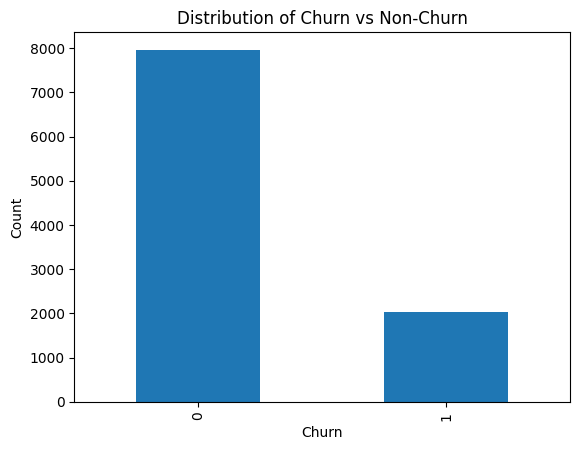

In [7]:
#Explanatory data analysis
#distibution of churn vs non-churn
data['churn'].value_counts().plot(kind='bar')
plt.title('Distribution of Churn vs Non-Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

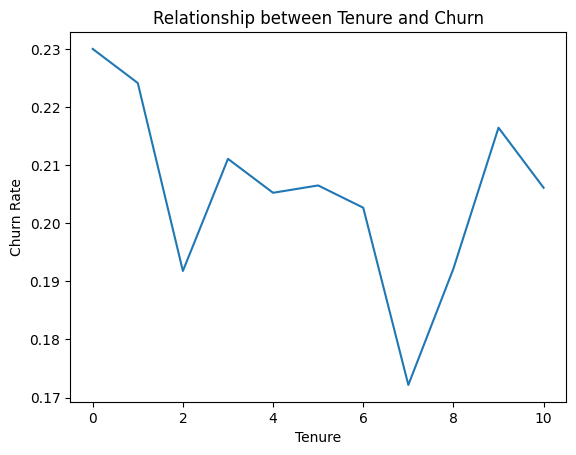

In [8]:
#relationship between tenure and churn
data.groupby('tenure')['churn'].mean().plot(kind='line')
plt.title('Relationship between Tenure and Churn')
plt.xlabel('Tenure')
plt.ylabel('Churn Rate')
plt.show()

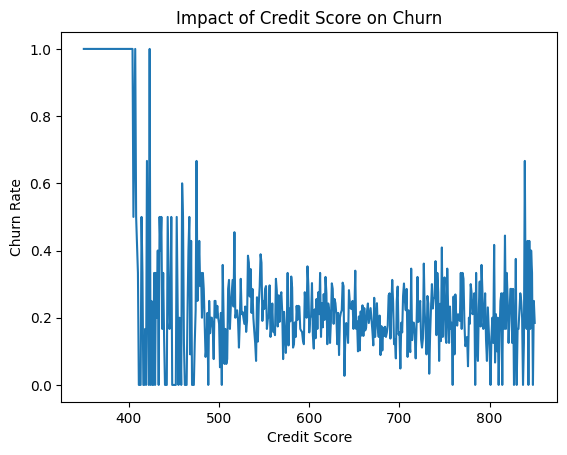

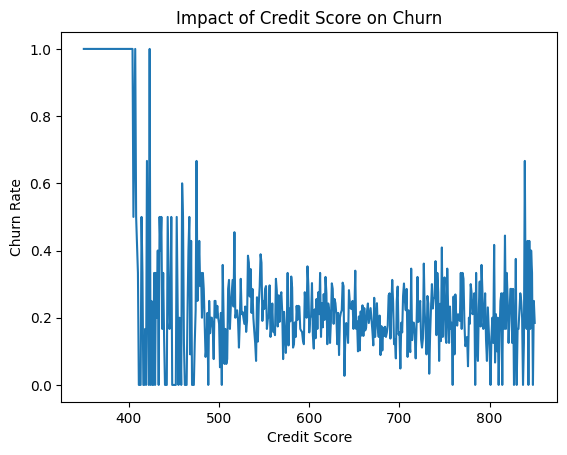

C:\Users\phatu\AppData\Local\Temp\ipykernel_11632\3759346073.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('Balance_Bucket')['balance'].mean().plot(kind='line')


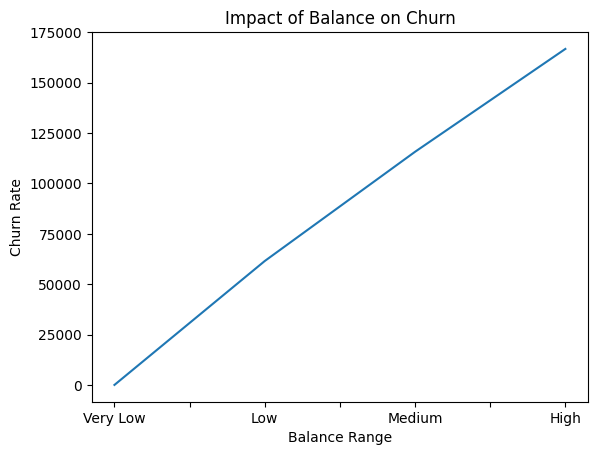

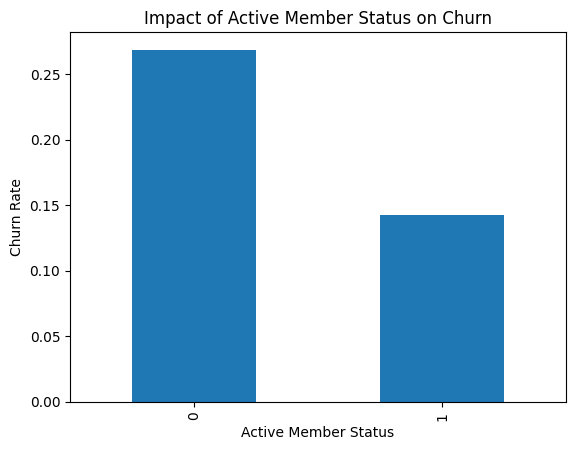

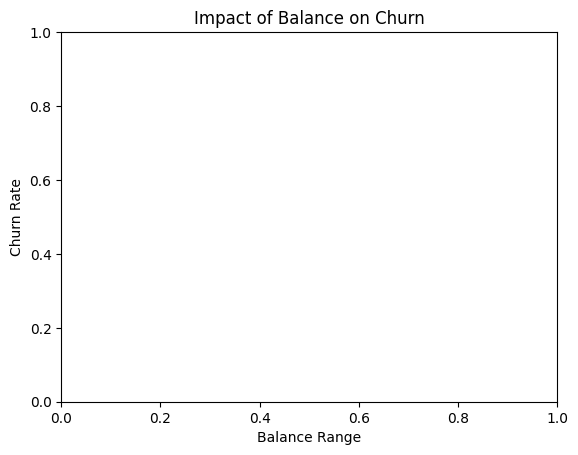

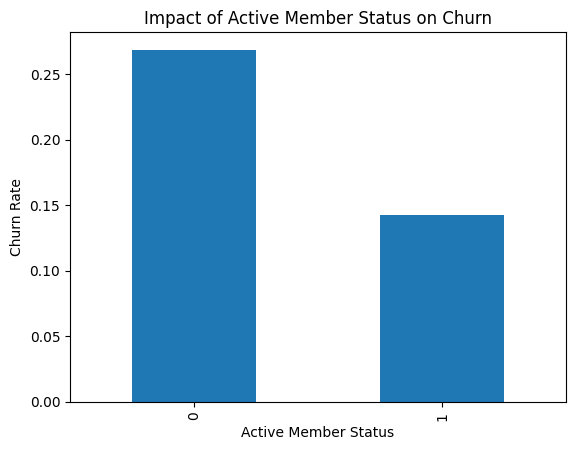

In [11]:
#impact of credit score, balance, active_member on churn
data.groupby('credit_score')['churn'].mean().plot(kind='line')
plt.title('Impact of Credit Score on Churn')
plt.xlabel('Credit Score')
plt.ylabel('Churn Rate')
plt.show()

#create balance buckets for better visualization
#Very Low (≤ 25k), Low (25k–75k), Medium (75k–150k) High (> 150k)
data['Balance_Bucket'] = pd.cut(data['balance'], bins=[-1, 25000, 75000, 150000, 250900],labels=['Very Low', 'Low', 'Medium', 'High'])
data = pd.get_dummies(data, columns=['Balance_Bucket'], drop_first=True)

#impact of credit score, balance, active_member on churn
data.groupby('credit_score')['churn'].mean().plot(kind='line')
plt.title('Impact of Credit Score on Churn')
plt.xlabel('Credit Score')
plt.ylabel('Churn Rate')
plt.show()

#create balance buckets for better visualization
#Very Low (≤ 25k), Low (25k–75k), Medium (75k–150k) High (> 150k)
data['Balance_Bucket'] = pd.cut(data['balance'], bins=[-1, 25000, 75000, 150000, 250900], labels=['Very Low', 'Low', 'Medium', 'High'])

data.groupby('Balance_Bucket')['balance'].mean().plot(kind='line')
plt.title('Impact of Balance on Churn')
plt.xlabel('Balance Range')
plt.ylabel('Churn Rate')
plt.show()

data = pd.get_dummies(data, columns=['Balance_Bucket'], drop_first=True)

data.groupby('active_member')['churn'].mean().plot(kind='bar')
plt.title('Impact of Active Member Status on Churn')
plt.xlabel('Active Member Status')
plt.ylabel('Churn Rate')
plt.show()
plt.title('Impact of Balance on Churn')
plt.xlabel('Balance Range')
plt.ylabel('Churn Rate')
plt.show()

data.groupby('active_member')['churn'].mean().plot(kind='bar')
plt.title('Impact of Active Member Status on Churn')
plt.xlabel('Active Member Status')
plt.ylabel('Churn Rate')
plt.show()





In [46]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Feature Engineering, I created two derived features to capture behavioral patterns not visible in raw data...
# Balance-to-Salary Ratio
data['balance_to_salary_ratio'] = data['balance'] / (data['estimated_salary'] + 1)

# Products per Tenure (avoid division by zero)
data['products_per_tenure'] = data['products_number'] / (data['tenure'] + 1)



# Feature Selection
features = data[['credit_score', 'balance', 'active_member', 'tenure', 'Gender',
                 'Balance_Bucket_Low', 'Balance_Bucket_Medium', 'Balance_Bucket_High',
                 'Age_Bucket_Middle-aged', 'Age_Bucket_Senior',
                 'estimated_salary', 'products_number',
                 'balance_to_salary_ratio', 'products_per_tenure']]
target = data['churn']

#Train/Test Split 
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=100)

#Resample with SMOTE
smote = SMOTE(random_state=100)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

#Train Logistic Regression
model = LogisticRegression(class_weight='balanced', max_iter=10000)
model.fit(X_train_resampled, y_train_resampled)

# Threshold Tuning
y_proba = model.predict_proba(X_test)[:, 1] 

thresholds = [0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_thresh))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thresh))



Threshold: 0.3
              precision    recall  f1-score   support

           0       0.89      0.57      0.69      1588
           1       0.30      0.72      0.43       412

    accuracy                           0.60      2000
   macro avg       0.59      0.64      0.56      2000
weighted avg       0.77      0.60      0.64      2000

Confusion Matrix:
 [[903 685]
 [115 297]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.86      0.70      0.77      1588
           1       0.33      0.58      0.42       412

    accuracy                           0.67      2000
   macro avg       0.60      0.64      0.60      2000
weighted avg       0.75      0.67      0.70      2000

Confusion Matrix:
 [[1109  479]
 [ 174  238]]

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1588
           1       0.40      0.48      0.43       412

    accuracy                           0.74   

c:\Users\phatu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Feature Importance:
 Age_Bucket_Senior          3.806672
Age_Bucket_Middle-aged     2.478157
Balance_Bucket_Medium      0.449311
Balance_Bucket_Low         0.393024
Balance_Bucket_High        0.368144
products_per_tenure        0.296719
balance_to_salary_ratio    0.001091
balance                    0.000002
estimated_salary           0.000001
credit_score              -0.000640
tenure                    -0.027893
products_number           -0.571178
Gender                    -1.160944
active_member             -1.623332
dtype: float64


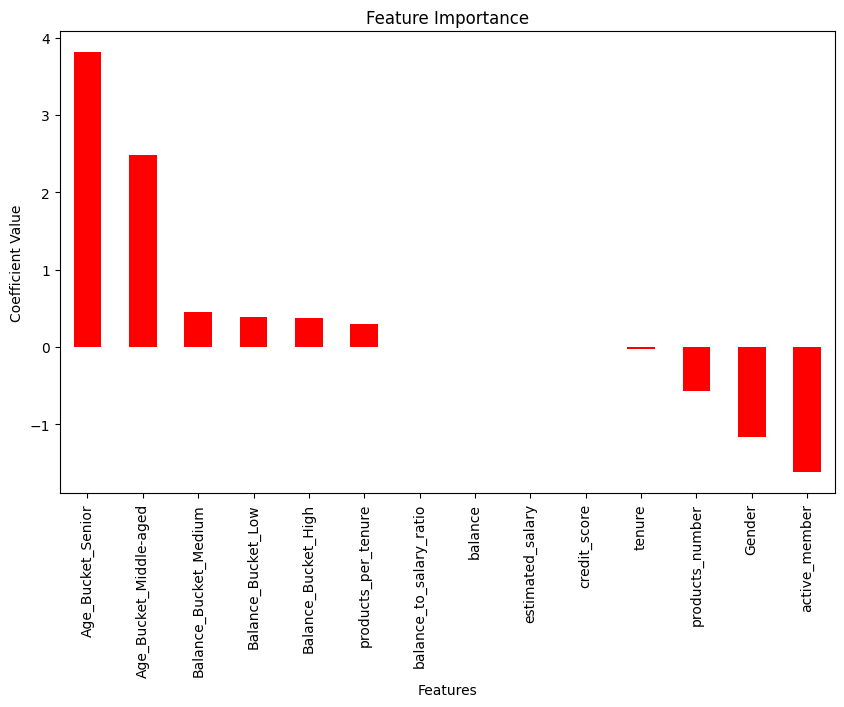

In [ ]:
#feature importance
feature_importance = pd.Series(model.coef_[0], index=features.columns).sort_values(ascending=False)
print("\nFeature Importance:\n",feature_importance)
#plotting feature importance
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar',color = 'red')
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.show()

In [43]:
#random forest for feature importance
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=100)
rf_model.fit(X_train_resampled, y_train_resampled)
rf_feature_importance = pd.Series(rf_model.feature_importances_, index=features.columns)
rf_feature_importance = rf_feature_importance.sort_values(ascending=False)
print("\nRandom Forest Feature Importance:\n", rf_feature_importance)


Random Forest Feature Importance:
 estimated_salary           0.117802
Age_Bucket_Senior          0.116057
products_per_tenure        0.110589
credit_score               0.109897
active_member              0.102123
products_number            0.101305
balance                    0.087975
balance_to_salary_ratio    0.083614
Gender                     0.062519
tenure                     0.059967
Age_Bucket_Middle-aged     0.024895
Balance_Bucket_Medium      0.002477
Balance_Bucket_Medium      0.002126
Balance_Bucket_Medium      0.001890
Balance_Bucket_Medium      0.001829
Balance_Bucket_Medium      0.001740
Balance_Bucket_Medium      0.001320
Balance_Bucket_High        0.001112
Balance_Bucket_Medium      0.001028
Balance_Bucket_High        0.000993
Balance_Bucket_High        0.000976
Balance_Bucket_High        0.000933
Balance_Bucket_High        0.000914
Balance_Bucket_Low         0.000766
Balance_Bucket_High        0.000758
Balance_Bucket_Low         0.000682
Balance_Bucket_Low         0

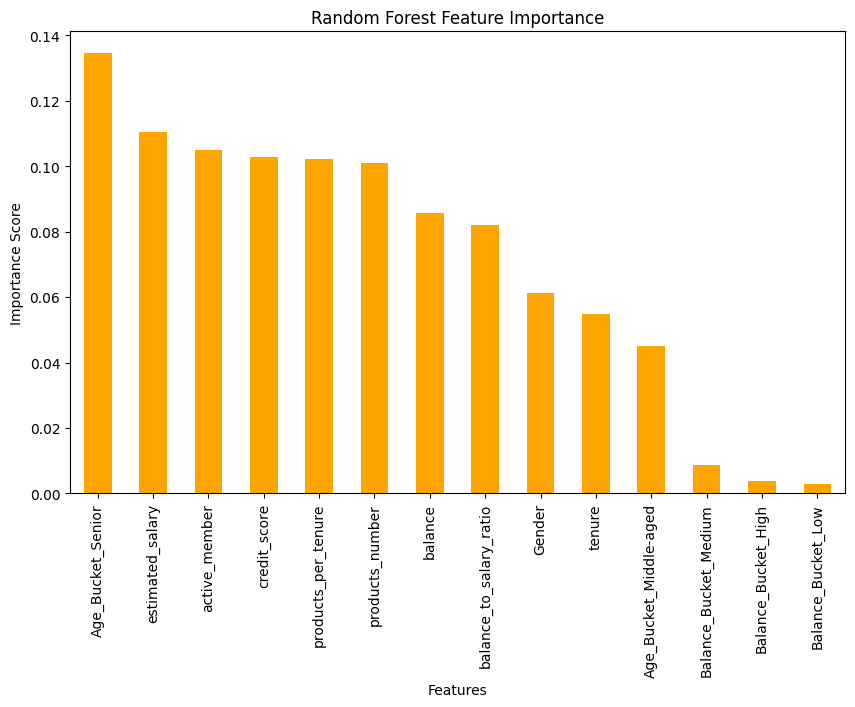

In [ ]:
#plotting random forest feature importance
plt.figure(figsize=(10, 6))
rf_feature_importance.plot(kind='bar', color='orange')
plt.title('Random Forest Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.show()


In [28]:
#churn risk score function
def churn_risk_score(row):
    score = 0
    
    # Age Bucket 
    if row['Age_Bucket'] == 'Young': score += 3
    elif row['Age_Bucket'] == 'Middle-aged': score += 2
    elif row['Age_Bucket'] == 'Senior': score += 1
    
    # Balance Bucket (dummy columns)
    if row['Balance_Bucket_Medium'] == 1:
        score += 2
    elif row['Balance_Bucket_Low'] == 1:
        score += 1
    else:  # if neither low nor medium, assume High
        score += 0
    
    # Active Member
    if row['active_member'] == 0:
        score += 3
    
    # Products Number
    if row['products_number'] == 1:
        score += 2
    
    # Products per Tenure
    if row['products_per_tenure'] < 0.5:
        score += 1
    
    return score

# Apply to dataset
# churn risk score function
def churn_risk_score(row):
    score = 0

    # Age Bucket from raw age
    if row['age'] <= 25:
        score += 3
    elif row['age'] <= 50:
        score += 2
    else:
        score += 1

    # Balance Bucket from raw balance
    if row['balance'] <= 25000:
        score += 1
    elif row['balance'] <= 75000:
        score += 2
    # High balance adds 0

    # Active Member
    if row['active_member'] == 0:
        score += 3

    # Products Number
    if row['products_number'] == 1:
        score += 2

    # Products per Tenure
    if row['products_per_tenure'] < 0.5:
        score += 1

    return score

data['churn_risk_score'] = data.apply(churn_risk_score, axis=1)


# Define risk levels
def risk_level(score):
    if score <= 3:
        return 'Low Risk'
    elif score <= 7:
        return 'Medium Risk'
    else:
        return 'High Risk'

data['risk_level'] = data['churn_risk_score'].apply(risk_level)

# Preview
print(data[['churn_risk_score','risk_level']].head())


   churn_risk_score   risk_level
0                 6  Medium Risk
1                 4  Medium Risk
2                 6  Medium Risk
3                 6  Medium Risk
4                 5  Medium Risk


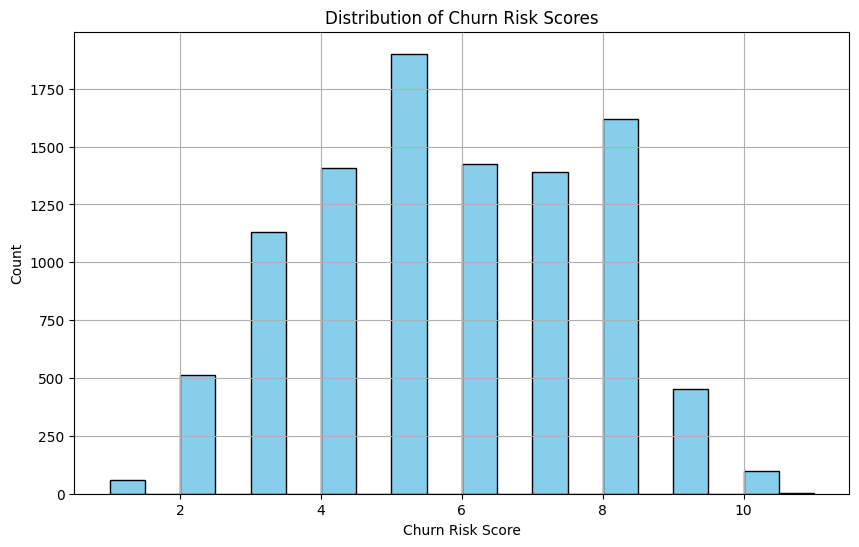

In [29]:
#plotting churn risk score distribution
plt.figure(figsize=(10, 6))
data['churn_risk_score'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Churn Risk Scores')
plt.xlabel('Churn Risk Score')
plt.ylabel('Count')
plt.show()

In [47]:
from sklearn.ensemble import RandomForestClassifier


# Model Comparison Summary
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_thresh))

try:
    print("Random Forest Accuracy:", accuracy_score(y_test, rf_model.predict(X_test)))
except NameError:
    rf_model = RandomForestClassifier(n_estimators=100, random_state=100)
    rf_model.fit(X_train_resampled, y_train_resampled)
    print("Random Forest Accuracy:", accuracy_score(y_test, rf_model.predict(X_test)))

Logistic Regression Accuracy: 0.743
Random Forest Accuracy: 0.8025


## Conclusion & Business Recommendations

### Model Performance Summary

| Model                                               | Accuracy |
|-----------------------------------------------------|----------|
| Logistic Regression (all features, threshold tuned) | 74%      |
| Random Forest (all features)                        | 81%      |
--------------------------------------------------------------------
**Selected Model: Random Forest** — achieves higher accuracy 
and captures non-linear relationships between features 
that Logistic Regression cannot model effectively.

### Key Churn Drivers Identified

Based on Random Forest feature importance analysis:

1. **Active Membership Status** — Inactive members are 
significantly more likely to churn. Targeted re-engagement 
campaigns should prioritize this segment.

2. **Balance-to-Salary Ratio** — Customers with low 
balance relative to salary show higher churn risk, 
suggesting they are not fully utilizing banking products.

3. **Products per Tenure** — Customers with fewer products 
relative to their tenure are at higher risk, indicating 
low product adoption and weak relationship depth.

### Business Recommendations

- **Retention Priority:** Flag all customers classified 
as High Risk (score > 7) for immediate relationship 
manager outreach.

- **Re-engagement Campaign:** Target inactive members 
(active_member = 0) with personalized product offers 
to increase engagement before churn occurs.

- **Product Cross-selling:** Customers with only 1 product 
and long tenure are underserved — proactively offer 
relevant products to deepen the relationship.

- **Early Warning System:** Deploy the churn risk scoring 
function as a monthly automated report to identify 
at-risk customers before they churn.

### Limitations & Next Steps

- Model performance could be improved with hyperparameter 
tuning using GridSearchCV
- Additional features such as customer service interactions 
and transaction frequency would likely improve prediction accuracy
- A/B testing the retention recommendations would validate 
the model's real-world impact